In [1]:
import pandas as pd
import glob
import seaborn as sns
import re
import os
import matplotlib.pyplot as plt

def results_scatterplot(results_folder, x_metric, y_metric, epochs = None, classes = None, color_by = "epoch", retrain = True, base_color = "black", retain_color = "purple"):

    # gather subdirectories
    all_subdirs = []
    for root, dirs, files in os.walk(results_folder):
        for d in dirs:
            
            all_subdirs.append(os.path.join(root, d))
    if epochs is not None:
        pattern = rf"_({'|'.join(map(str, epochs))})$"
        all_subdirs = [d for d in all_subdirs if re.search(pattern, d)]

    if not retrain:
        pattern = rf"retrain"
        all_subdirs = [d for d in all_subdirs if not re.search(pattern, d)]

    # print(all_subdirs)
        

    # gather results
    all_results = []
    for subdir in all_subdirs:

        # grab json files in this subdir
        file_paths = glob.glob(os.path.join(subdir, "*.json"))
        
        # Apply all filters immediately
        file_paths = [f for f in file_paths if "config" not in f]
        
        if classes is not None:
            pattern = rf"class_({'|'.join(map(str, classes))})"
            file_paths = [f for f in file_paths if re.search(pattern, f)]
        
        # Check if anything is left AFTER filtering
        if not file_paths:
            # print(f"Skipping {subdir}: No matching JSONs after filtering.")
            continue
        # else:
            # print(f"Found some in {subdir}, adding data...")
        
        # add jsons for these file paths
        all_jsons = []
        for f in file_paths:
            data = pd.read_json(f, typ='series')
            # add class if none
            match = re.search(r'class_(\d+)', f)
            if match:
                data['class'] = int(match.group(1))
            else:
                data['class'] = -99  # default value if no match

            # add epoch if none
            match = re.search(r'base', f)
            if match:
                data['epoch'] = -99

            match = re.search(r'retrain', f)
            if match:
                data['epoch'] = -98

            all_jsons.append(data)

        # and concat and append to main df
        df = pd.concat(all_jsons, axis=1).T
        all_results.append(df)
    final_df = pd.concat(all_results, axis=0)


    # set up colors
    unique_epochs = sorted(final_df[color_by].unique())
    colors_list = plt.cm.tab20.colors
    palette_dict = {}
    color_idx = 0
    for epoch in unique_epochs:
        if epoch == -99:
            palette_dict[epoch] = base_color
        elif epoch == -98:
            palette_dict[epoch] = retain_color
        else:
            # Use modulo to cycle through tab20 if you have more than 20 epochs
            palette_dict[epoch] = colors_list[color_idx % len(colors_list)]
            color_idx += 1

    # plot
    plt.clf()
    sns.set_style("whitegrid")
    sns.scatterplot(
        data=final_df, 
        x=x_metric, 
        y=y_metric, 
        hue=color_by, 
        palette=palette_dict,  # Use the mapping dictionary here
        alpha=0.7,
        edgecolor=None
    )
    # Formatting
    plt.title(f"{x_metric} vs. {y_metric}")
    plt.xlabel(x_metric.capitalize().replace("_", " "))
    plt.ylabel(y_metric.capitalize().replace("_", " "))
    handles, labels = plt.gca().get_legend_handles_labels()
    # 2. Replace -99 (or -99.0) with "base" in the labels list
    new_labels = ["base" if label == "-99" or label == "-99.0" else "retrain" if label == "-98" or label == "-98.0" else label for label in labels]
    plt.legend(title=color_by.capitalize(), handles = handles, labels = new_labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    # plt.xlim(.6, .95)
    # plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    return final_df

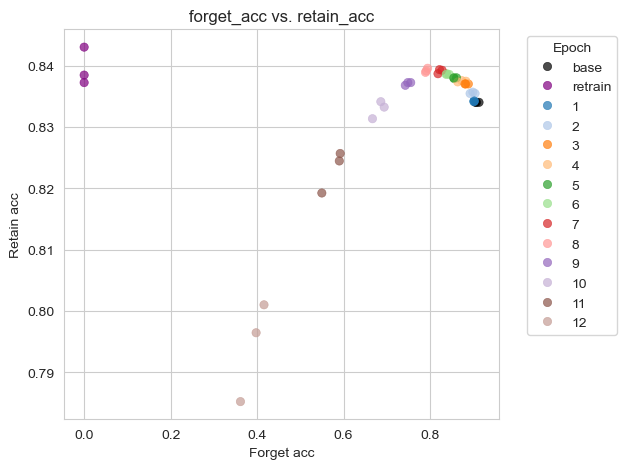

In [2]:
results = results_scatterplot("results/seed_2/", x_metric = "forget_acc", y_metric = "retain_acc", epochs=None, classes = None, color_by = "epoch", retrain = True)

In [3]:
results

,name,epoch,forget_acc,retain_acc,type,class
0,retrain_run_1_class_0,-98,0.0,0.838444,retrain,0
1,retrain_run_2_class_0,-98,0.0,0.843,retrain,0
2,retrain_run_3_class_0,-98,0.0,0.837222,retrain,0
0,base_run_2_class_0,-99,0.905333,0.834,base,0
1,base_run_3_class_0,-99,0.913333,0.834,base,0
2,base_run_1_class_0,-99,0.907333,0.834,base,0
0,class_0,9,0.748667,0.837222,unlearn,0
0,class_0,7,0.822,0.839333,unlearn,0
0,class_0,6,0.838667,0.838667,unlearn,0
0,class_0,1,0.902667,0.834222,unlearn,0
